# Notebook 1: Gillespie SSA and Neural SDE Simulation

This notebook demonstrates the two simulation components of `crn_surrogate`:

1. **Gillespie SSA** — the exact stochastic simulator used to generate ground-truth trajectories.
2. **Neural SDE forward pass** — running the encoder + neural SDE on an untrained network to verify shapes and structure.

The reference CRNs used here are:
- **Birth-death process**: `∅ ⇌ A`, analytical stationary distribution is Poisson(k₁/k₂)
- **Lotka-Volterra**: predator-prey oscillations with two species

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Make plots look clean
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## 1. Gillespie SSA — Birth-Death Process

The birth-death process is the simplest CRN:
- **Birth**: `∅ → A` at rate `k₁`
- **Death**: `A → ∅` at rate `k₂`

The stationary distribution is `Poisson(k₁/k₂)`, so the mean is `k₁/k₂ = 4`.

In [2]:
from crn_surrogate.crn.examples import birth_death
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

k1, k2 = 2.0, 0.5  # steady-state mean = k1/k2 = 4
crn_bd = birth_death(k_birth=k1, k_death=k2)
crn_bd_repr = crn_to_tensor_repr(crn_bd)
print(crn_bd)
print(f"Stoichiometry matrix:\n{crn_bd.stoichiometry_matrix}")
print(f"Dependency matrix:\n{crn_bd_repr.dependency_matrix}")

CRN(n_species=1, n_reactions=2, species=('A',))
Stoichiometry matrix:
tensor([[ 1.],
        [-1.]])
Dependency matrix:
tensor([[0.],
        [1.]])


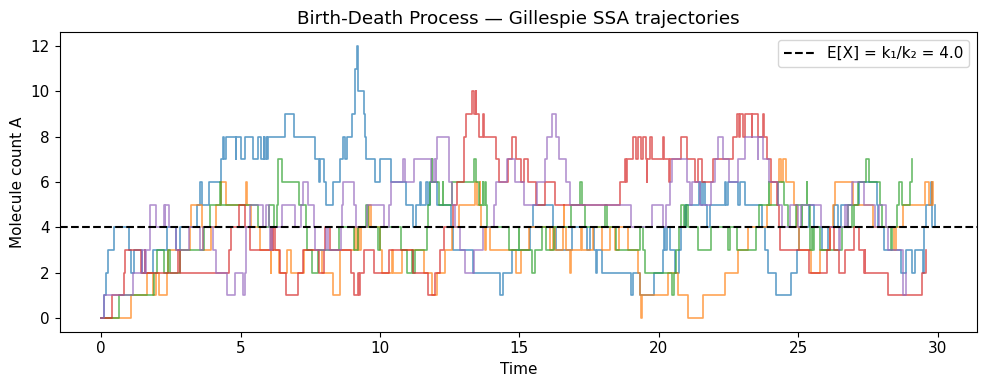

Number of reaction events per trajectory: [142, 111, 118, 116, 119]


In [3]:
ssa = GillespieSSA()

# Run 5 independent trajectories
n_trajs = 5
t_max = 30.0
trajs_bd = [
    ssa.simulate(
        stoichiometry=crn_bd.stoichiometry_matrix,
        propensity_fn=crn_bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=t_max,
    )
    for _ in range(n_trajs)
]

fig, ax = plt.subplots(figsize=(10, 4))
for traj in trajs_bd:
    ax.step(traj.times.numpy(), traj.states[:, 0].numpy(), where='post', alpha=0.7, linewidth=1.2)
ax.axhline(k1 / k2, color='black', linestyle='--', linewidth=1.5, label=f'E[X] = k₁/k₂ = {k1/k2}')
ax.set_xlabel('Time')
ax.set_ylabel('Molecule count A')
ax.set_title('Birth-Death Process — Gillespie SSA trajectories')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Number of reaction events per trajectory: {[t.n_steps for t in trajs_bd]}")

### Stationary distribution check

We sample many trajectories and collect final states. The empirical distribution should match `Poisson(k₁/k₂)`.

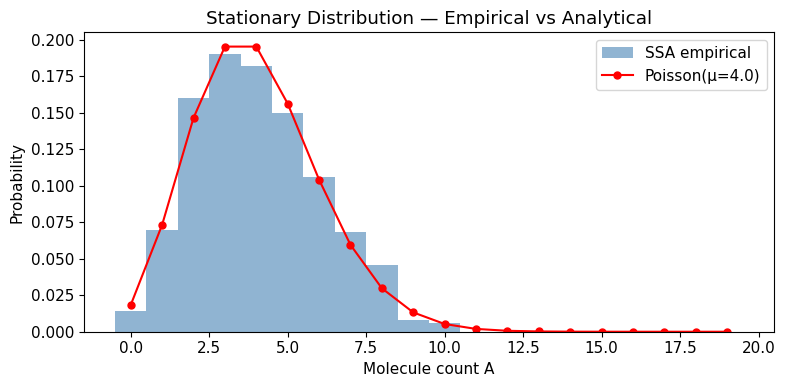

Empirical mean: 4.05  (expected: 4.0)
Empirical std:  2.00  (expected: 2.00)


In [4]:
from scipy.stats import poisson

n_samples = 500
final_counts = [
    ssa.simulate(
        stoichiometry=crn_bd.stoichiometry_matrix,
        propensity_fn=crn_bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=50.0,
    ).states[-1, 0].item()
    for _ in range(n_samples)
]
final_counts = np.array(final_counts, dtype=int)

mu = k1 / k2
x_vals = np.arange(0, 20)
poisson_pmf = poisson.pmf(x_vals, mu)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(final_counts, bins=np.arange(-0.5, 20.5), density=True, alpha=0.6, color='steelblue', label='SSA empirical')
ax.plot(x_vals, poisson_pmf, 'ro-', markersize=5, label=f'Poisson(μ={mu})')
ax.set_xlabel('Molecule count A')
ax.set_ylabel('Probability')
ax.set_title('Stationary Distribution — Empirical vs Analytical')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Empirical mean: {np.mean(final_counts):.2f}  (expected: {mu})")
print(f"Empirical std:  {np.std(final_counts):.2f}  (expected: {np.sqrt(mu):.2f})")

## 2. Gillespie SSA — Lotka-Volterra

The Lotka-Volterra (predator-prey) system has two species and exhibits oscillatory dynamics:
- `A → 2A` (prey birth, rate k₁)
- `A + B → 2B` (predation, rate k₂)
- `B → ∅` (predator death, rate k₃)

In [5]:
from crn_surrogate.crn.examples import lotka_volterra

crn_lv = lotka_volterra(k_prey_birth=1.0, k_predation=0.005, k_predator_death=0.6)
crn_lv_repr = crn_to_tensor_repr(crn_lv)
print(crn_lv)

traj_lv = ssa.simulate(
    stoichiometry=crn_lv.stoichiometry_matrix,
    propensity_fn=crn_lv.evaluate_propensities,
    initial_state=torch.tensor([100.0, 40.0]),
    t_max=50.0,
    max_reactions=500_000,
)
print(f"LV trajectory: {traj_lv.n_steps} events")

CRN(n_species=2, n_reactions=3, species=('prey', 'predator'))
LV trajectory: 17316 events


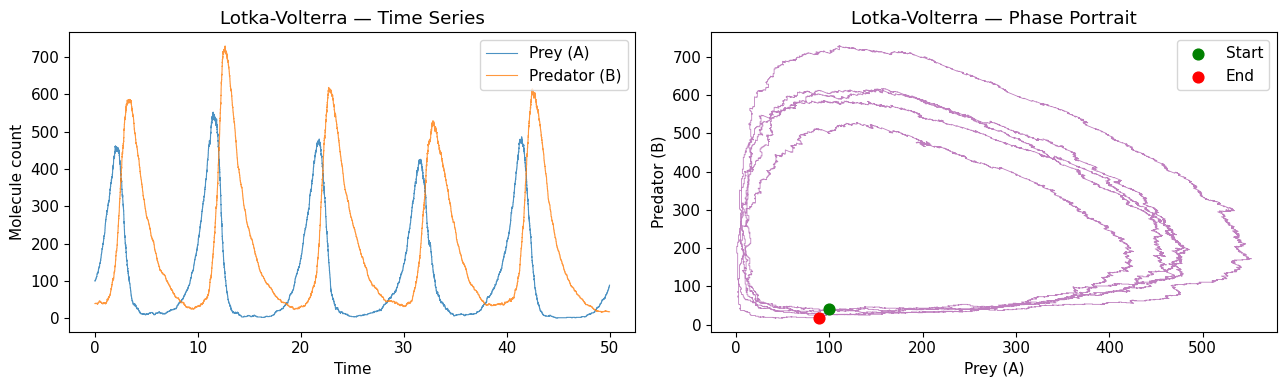

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time series
ax = axes[0]
times = traj_lv.times.numpy()
states = traj_lv.states.numpy()
ax.step(times, states[:, 0], where='post', color='tab:blue', alpha=0.8, label='Prey (A)', linewidth=0.8)
ax.step(times, states[:, 1], where='post', color='tab:orange', alpha=0.8, label='Predator (B)', linewidth=0.8)
ax.set_xlabel('Time')
ax.set_ylabel('Molecule count')
ax.set_title('Lotka-Volterra — Time Series')
ax.legend()

# Phase portrait
ax = axes[1]
ax.plot(states[:, 0], states[:, 1], alpha=0.5, linewidth=0.6, color='purple')
ax.scatter(states[0, 0], states[0, 1], color='green', s=60, zorder=5, label='Start')
ax.scatter(states[-1, 0], states[-1, 1], color='red', s=60, zorder=5, label='End')
ax.set_xlabel('Prey (A)')
ax.set_ylabel('Predator (B)')
ax.set_title('Lotka-Volterra — Phase Portrait')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Bipartite Graph Structure

The CRN defines a bipartite graph between species nodes and reaction nodes.
Let's inspect the edge structure extracted by `build_bipartite_edges`.

In [ ]:
from crn_surrogate.encoder.graph_utils import EdgeFeature

edges = crn_lv_repr.bipartite_edges

print(f"Edge feature dim: {edges.edge_feat_dim}  (channels: {[f.name for f in EdgeFeature]})")
print()
print("Reaction → Species edges:")
print(f"  index shape: {edges.rxn_to_species_index.shape}")
for i in range(edges.rxn_to_species_index.shape[1]):
    r = edges.rxn_to_species_index[0, i].item()
    s = edges.rxn_to_species_index[1, i].item()
    feat = edges.rxn_to_species_feat[i]
    sname = crn_lv.species_names[s]
    net   = feat[EdgeFeature.NET_CHANGE].item()
    stoic = feat[EdgeFeature.IS_STOICHIOMETRIC].item()
    dep   = feat[EdgeFeature.IS_DEPENDENCY].item()
    print(f"  rxn {r} ↔ {sname}: net_change={net:+.0f}  is_stoich={stoic:.0f}  is_dep={dep:.0f}")

## 4. CRN Encoder — Bipartite GNN

The encoder takes a CRN and an initial state, and runs `L` rounds of bipartite message passing to produce contextualized species and reaction embeddings.

At this point the network is untrained (random weights), so the embeddings are not meaningful — but we can verify shapes and that gradients flow.

In [8]:
from crn_surrogate.configs.model_config import EncoderConfig, SDEConfig, ModelConfig
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder

enc_config = EncoderConfig(d_model=32, n_layers=4)
encoder = BipartiteGNNEncoder(enc_config)

n_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {n_params:,}")

# Encode the Lotka-Volterra CRN
init_state = torch.tensor([100.0, 40.0])
ctx = encoder(crn_lv_repr, init_state)

print(f"\nSpecies embeddings: {ctx.species_embeddings.shape}")
print(f"Reaction embeddings: {ctx.reaction_embeddings.shape}")
print(f"Context vector: {ctx.context_vector.shape}")
print(f"Context vector norm: {ctx.context_vector.norm().item():.4f}")

Encoder parameters: 20,472

Species embeddings: torch.Size([2, 32])
Reaction embeddings: torch.Size([3, 32])
Context vector: torch.Size([64])
Context vector norm: 7.8937


## 5. Neural SDE — Forward Pass

The neural SDE takes the CRN context vector and the current state, and returns drift and diffusion coefficients. The Euler-Maruyama solver integrates forward in time.

The network is untrained here, so trajectories look like random walks — training is covered in notebook 3.

In [9]:
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.simulator.sde_solver import EulerMaruyamaSolver

sde_config = SDEConfig(d_model=32, d_hidden=64, n_noise_channels=8, clip_state=True)
sde = CRNNeuralSDE(sde_config, n_species=2)
solver = EulerMaruyamaSolver(sde_config)

n_sde_params = sum(p.numel() for p in sde.parameters())
print(f"Neural SDE parameters: {n_sde_params:,}")

t_span = torch.linspace(0.0, 20.0, 100)

# Run K=5 independent SDE trajectories from the same initial condition
K = 5
sde_trajs = [
    solver.solve(sde, init_state.clone(), ctx, t_span, dt=0.1)
    for _ in range(K)
]

print(f"\nSDE trajectory shape: {sde_trajs[0].states.shape}")

Neural SDE parameters: 12,214

SDE trajectory shape: torch.Size([100, 2])


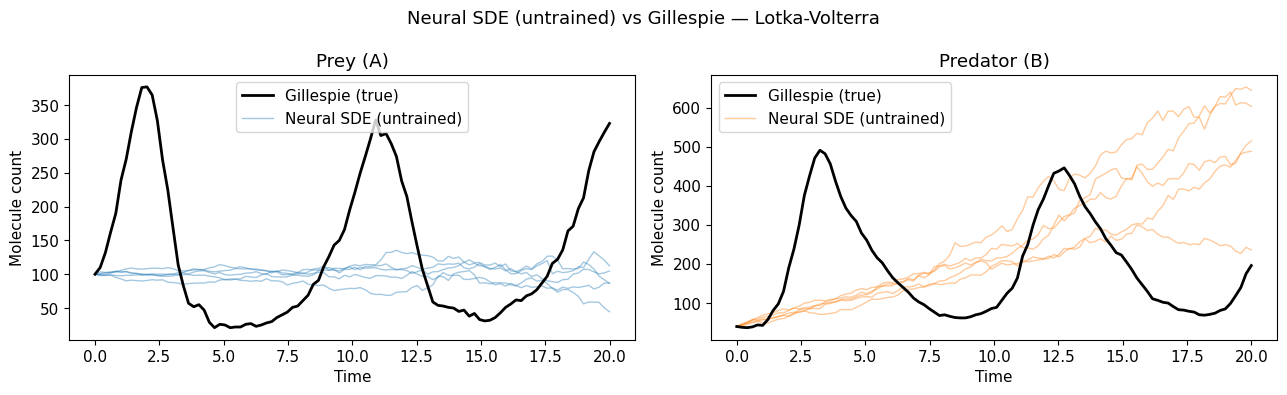

Note: the neural SDE is untrained, so it does not reproduce the Gillespie dynamics.
After training (notebook 3), the SDE will learn to approximate the true trajectories.


In [10]:
# Run a fresh Gillespie trajectory for visual comparison
traj_ref = ssa.simulate(
    stoichiometry=crn_lv.stoichiometry_matrix,
    propensity_fn=crn_lv.evaluate_propensities,
    initial_state=init_state.clone(),
    t_max=20.0,
    max_reactions=200_000,
)
grid_states = interpolate_to_grid(traj_ref.times, traj_ref.states, t_span)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
species_labels = ['Prey (A)', 'Predator (B)']
colors = ['tab:blue', 'tab:orange']

for sp in range(2):
    ax = axes[sp]
    # Gillespie ground truth
    ax.plot(t_span.numpy(), grid_states[:, sp].numpy(),
            color='black', linewidth=2, label='Gillespie (true)', zorder=3)
    # Neural SDE samples (untrained)
    for k, traj in enumerate(sde_trajs):
        ax.plot(t_span.numpy(), traj.states[:, sp].detach().numpy(),
                color=colors[sp], alpha=0.4, linewidth=1.0,
                label='Neural SDE (untrained)' if k == 0 else '')
    ax.set_xlabel('Time')
    ax.set_ylabel('Molecule count')
    ax.set_title(f'{species_labels[sp]}')
    ax.legend()

fig.suptitle('Neural SDE (untrained) vs Gillespie — Lotka-Volterra', fontsize=13)
plt.tight_layout()
plt.show()

print("Note: the neural SDE is untrained, so it does not reproduce the Gillespie dynamics.")
print("After training (notebook 3), the SDE will learn to approximate the true trajectories.")

## 6. Other Reference CRNs

The library includes five reference CRNs. Let's quickly visualise them all.

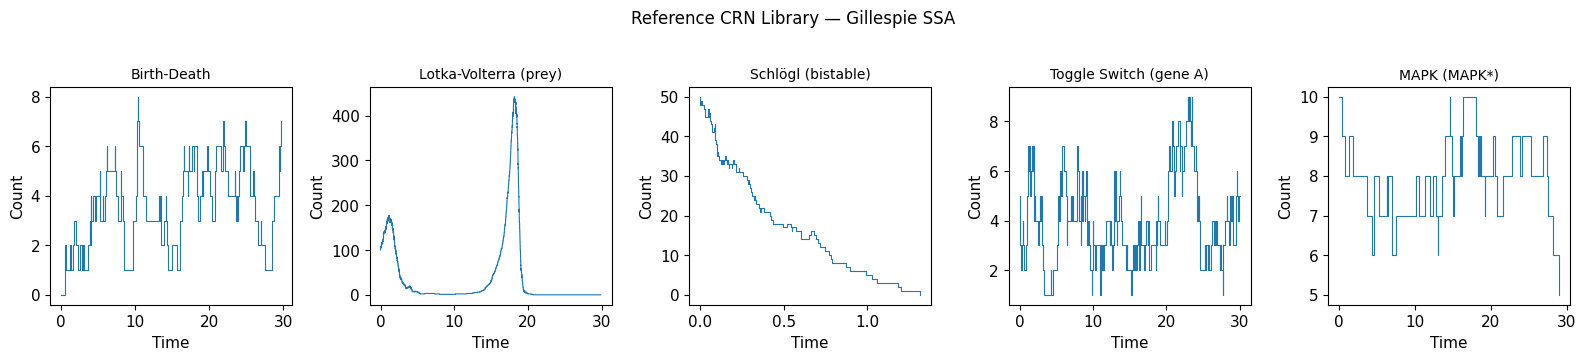

In [15]:
from crn_surrogate.crn.examples import schlogl, toggle_switch, simple_mapk_cascade

reference_crns = [
    (birth_death(k_birth=2.0, k_death=0.5),            torch.tensor([0.0]),         'Birth-Death'),
    (lotka_volterra(),                                   torch.tensor([100.0, 40.0]), 'Lotka-Volterra (prey)'),
    (schlogl(),                                          torch.tensor([50.0]),        'Schlögl (bistable)'),
    (toggle_switch(),                                    torch.tensor([5.0, 5.0]),    'Toggle Switch (gene A)'),
    (simple_mapk_cascade(),      torch.tensor([10, 0.0, 10.0, 0.0, 10.0, 0.0, 100]), 'MAPK (MAPK*)'),
]
fig, axes = plt.subplots(1, len(reference_crns), figsize=(16, 3.5))

for ax, (crn, init, label) in zip(axes, reference_crns):
    traj = ssa.simulate(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init.clone(),
        t_max=30.0,
        max_reactions=200_000,
    )
    # Plot first species only for simplicity
    ax.step(traj.times.numpy(), traj.states[:, 0].numpy(), where='post', linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Count')

plt.suptitle('Reference CRN Library — Gillespie SSA', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()